In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, ScalarFormatter
from Star_Model.Class import StarModel

# Usage Example

Initializing an object

In [2]:
estrella=StarModel(5,0.75,0.2,40,12,1.5)

Calculation of the not optimized star along with the relative error percentage.

In [3]:
estrella.calculate(optimizar=False)
estrella.error()

69.33172822513252

Calculation of the optimized star alongside a color map showing the minimum point of the luminosity-radius pair.

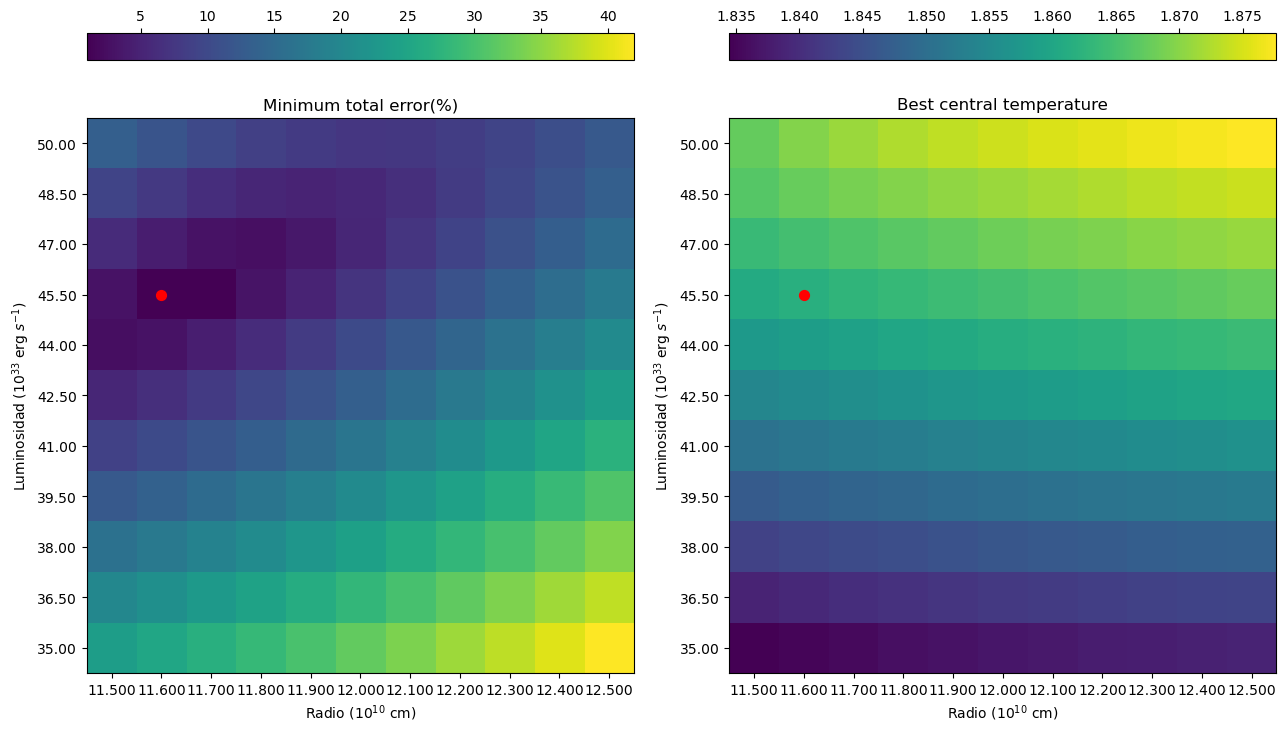

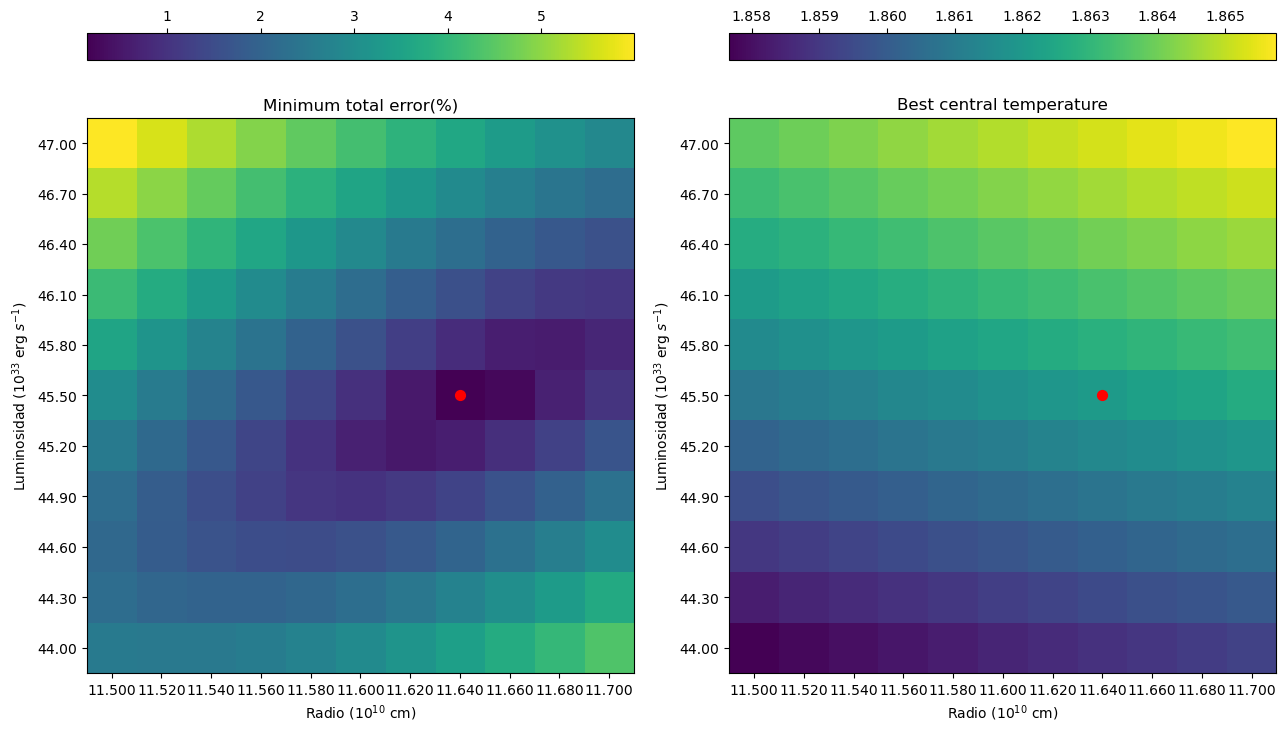

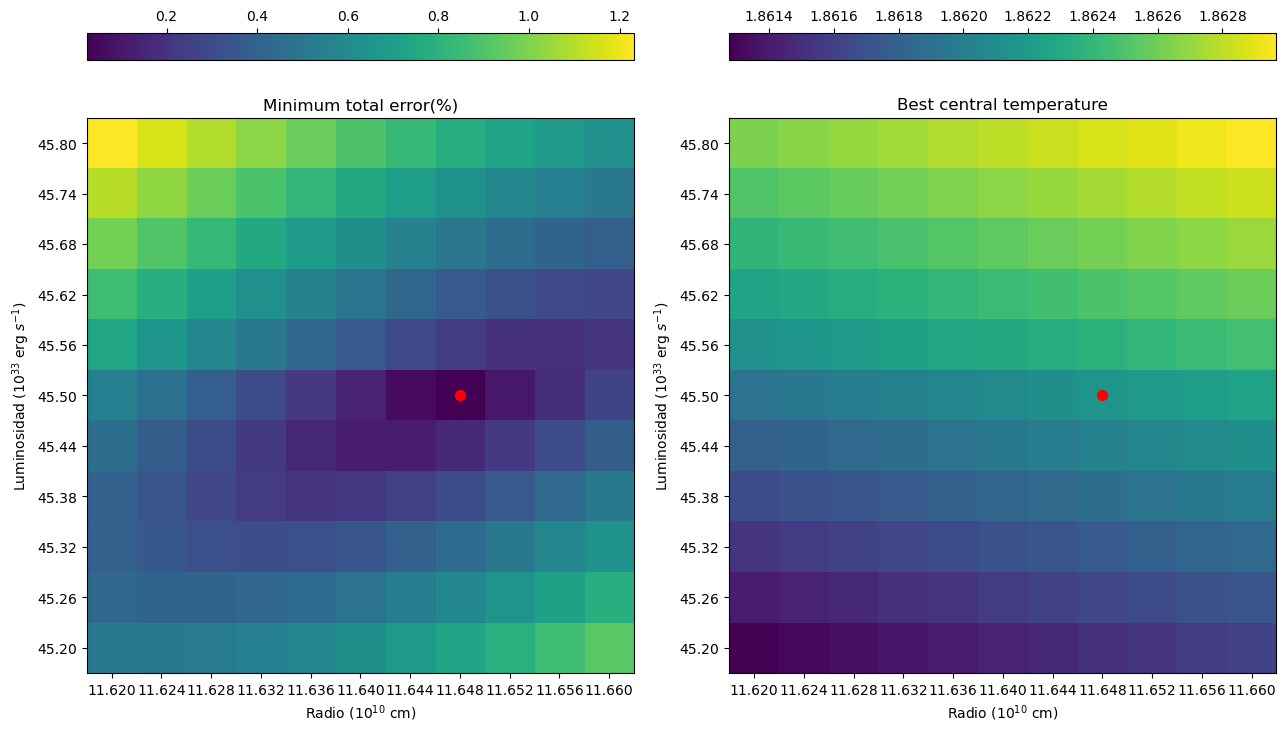

Los parámetros óptimos de la estrella corresponden a una temperatura central 1.86215·10⁷ K con una tolerancia de 1e-05, un radio total de 11.648·10¹⁰ cm con una tolerancia de 0.020 y una luminosidad total de 45.50·10³³ erg/s con una tolerancia de 0.30 todo ello con un error relativo del 0.02361%.


In [4]:
estrella.calculate(all_mallados=True)

With the optimized star, let's analyze how the different magnitudes vary from layer to layer.

In [5]:
estrella.layers()

  E     fase      i        r            P            T            L            M          n+1            ρ            ε            κ
  --   ˆˆˆˆˆˆ   -11    11.63635    0.0000000    0.0004880    45.500000     5.000000     0.000000     0.000000     0.000000    28.328047
  --   ˆˆˆˆˆˆ   -10    11.53152    0.0000000    0.0049241    45.500000     5.000000     0.000000     0.000000     0.000000    15.894031
  --   ˆˆˆˆˆˆ    -9    11.42669    0.0000000    0.0094416    45.500000     5.000000     0.000000     0.000003     0.000000    13.506851
  --   ˆˆˆˆˆˆ    -8    11.32186    0.0000002    0.0140427    45.500000     5.000000     0.000000     0.000011     0.000000    12.230728
  --   ˆˆˆˆˆˆ    -7    11.21702    0.0000007    0.0187299    45.500000     5.000000     0.000000     0.000027     0.000000    11.381026
  --   ˆˆˆˆˆˆ    -6    11.11219    0.0000018    0.0235055    45.500000     5.000000     0.000000     0.000056     0.000000    10.752833
  --   ˆˆˆˆˆˆ    -5    11.00736    0.0000041    0.0

Let's calculate the star's effective temperature!

In [6]:
print(estrella.effective_temp())

8282.687541294374


Plot of the density-temperature curve.

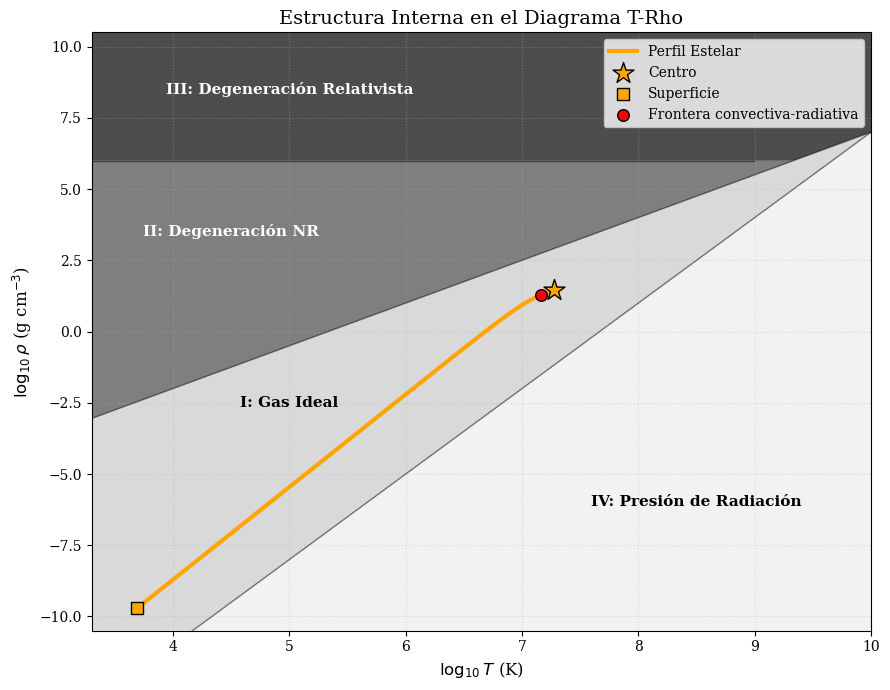

In [7]:
estrella.TDplane()

Location of the star on the HR diagram.

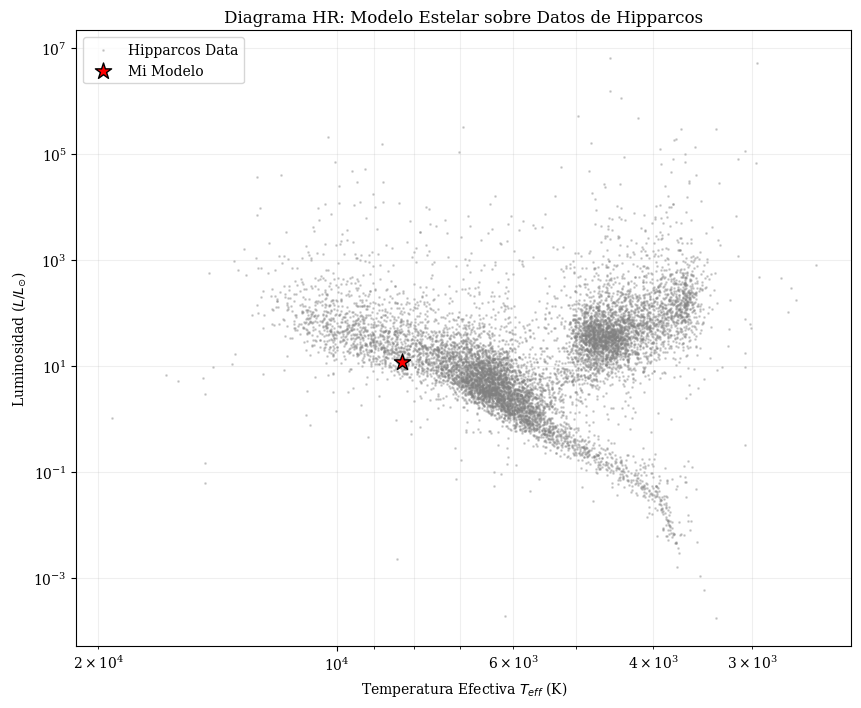

In [8]:
estrella.HR()

Now for the spectrum!

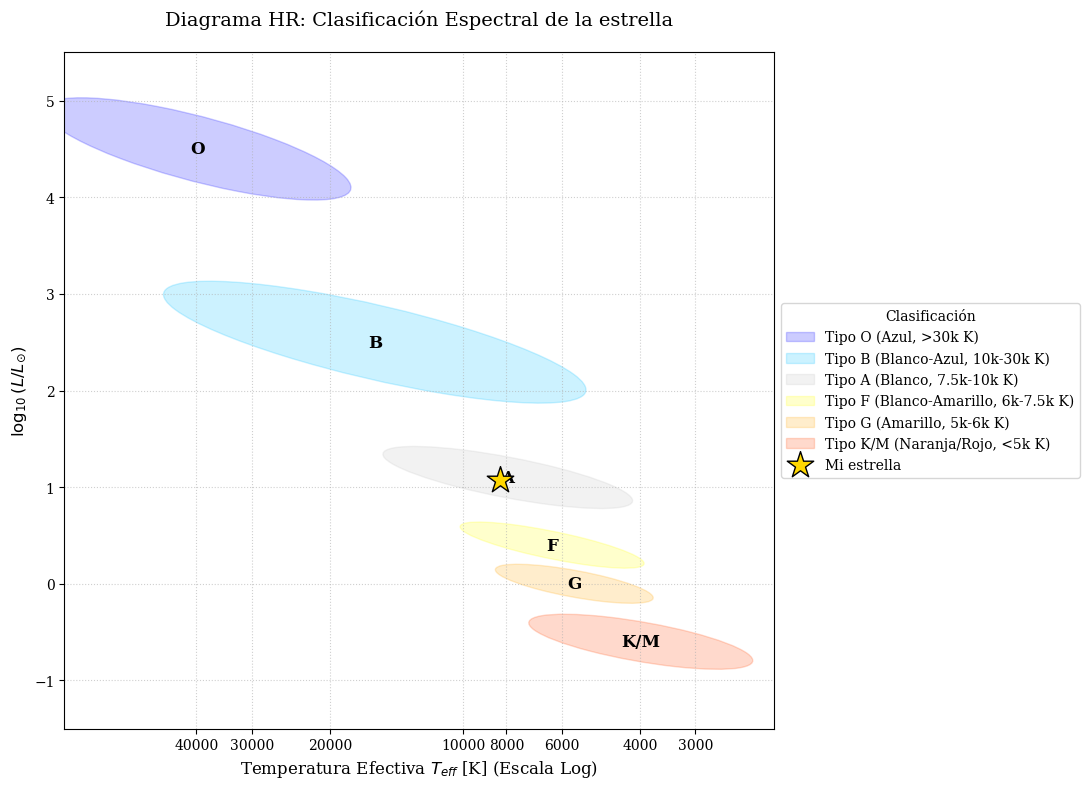

--- RESULTADOS ---
Temperatura efectiva calculada: 8282.69 K
Estrella clase A (Blanco)


In [9]:
estrella.Spectral()

Now, let's plot some graphs showing how these quantities vary across the star!!! First, let's look at the radius.

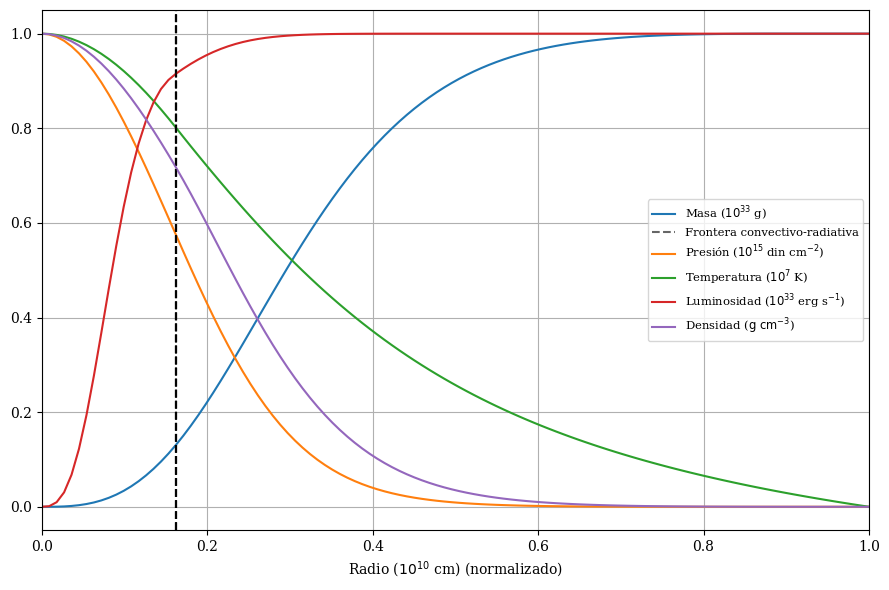

In [10]:
estrella.charts(which=['M','P','T','L','rho'])

Now, regarding the mass.

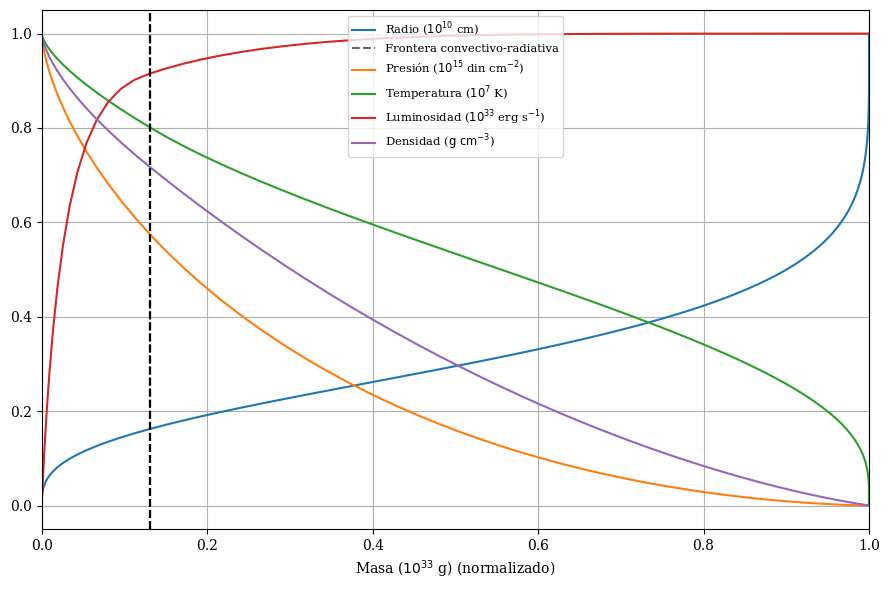

In [11]:
estrella.charts(x_axis='M', which=['r','P','T','L','rho'])

Let's plot the opacity and the rate of energy generation.

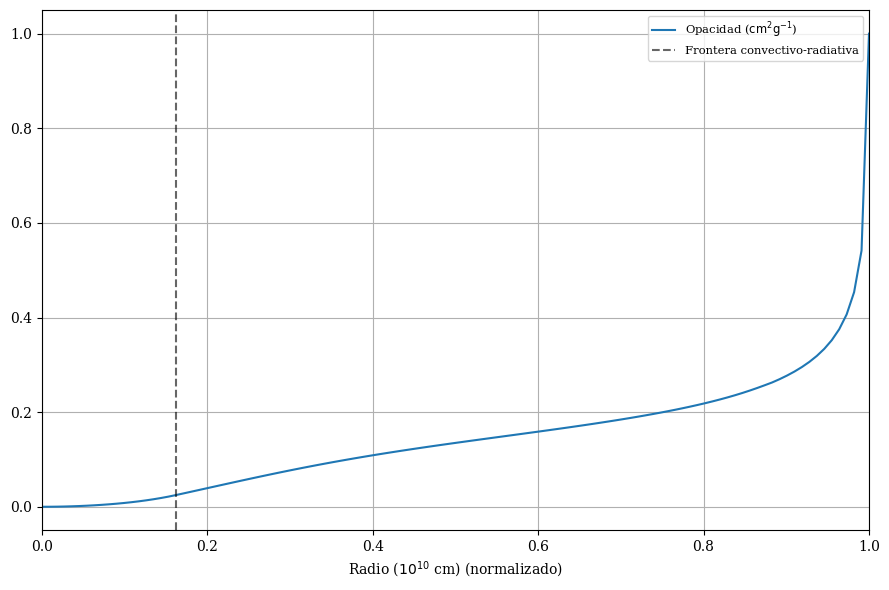

In [12]:
estrella.charts(which=['kappa'])

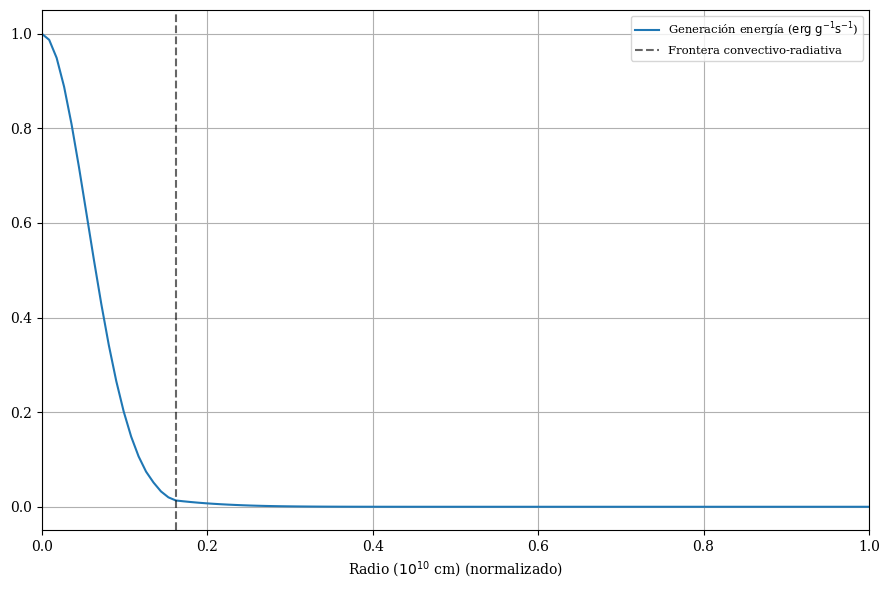

In [13]:
estrella.charts(which=['epsilon'])

Look at the values of the quantities at the boundary!

In [14]:
_=estrella.border_point()


DATOS EN LA BASE DE LA ZONA CONVECTIVA
Radio (r):             1.9874 · 10¹⁰ cm
Presión (P):          39.2246 · 10¹⁵ din/cm²
Temperatura (T):       1.4572 · 10⁷ K
Luminosidad (L):      42.1176 · 10³³ erg/s
Masa (M):              0.7469 · 10³³ g
Densidad (ρ):          19.3287 · g/cm³
Ritmo de gen. de energía (ε):              4.6812 · erg/g/s
Opacidad (κ):              1.9655 · cm²/g
----------------------------------------
Punto de corte: n = 2.5



Let's apply the model to another star!

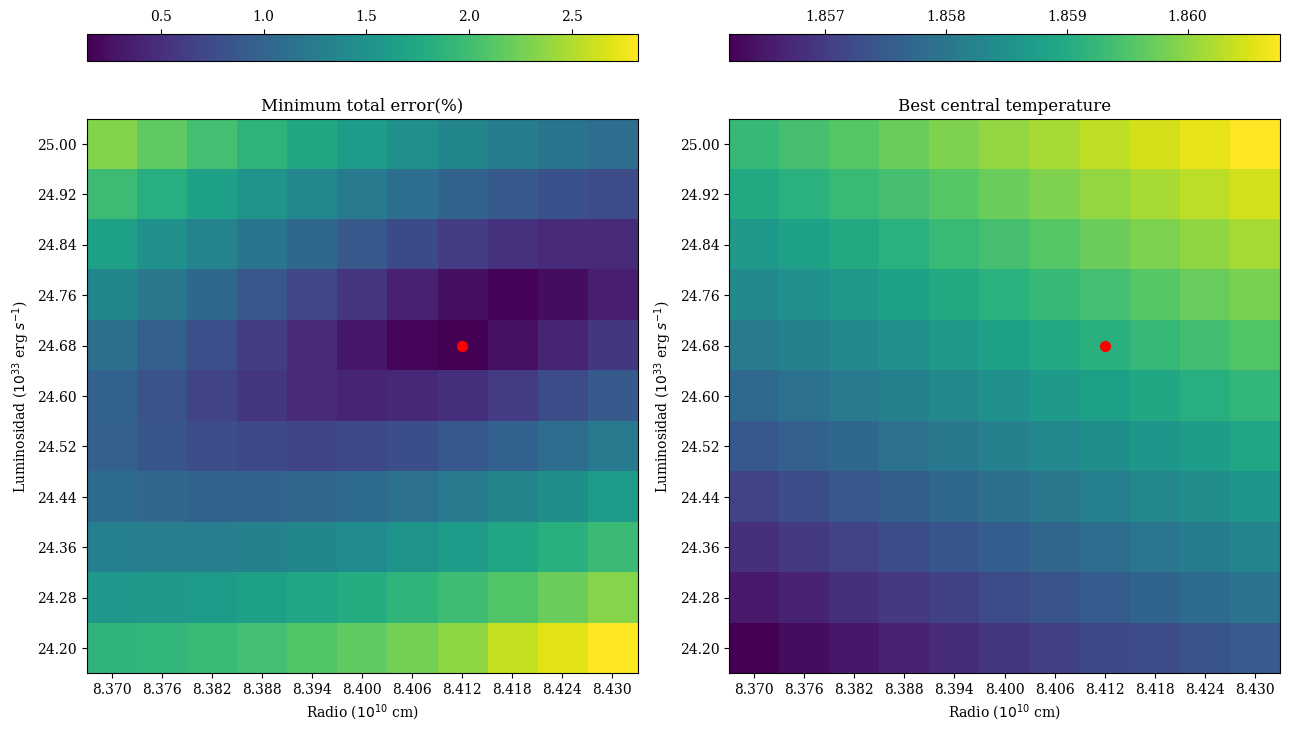

Los parámetros óptimos de la estrella corresponden a una temperatura central 1.85911·10⁷ K con una tolerancia de 1e-05, un radio total de 8.412·10¹⁰ cm con una tolerancia de 0.030 y una luminosidad total de 24.68·10³³ erg/s con una tolerancia de 0.40 todo ello con un error relativo del 0.13771%.


In [15]:
Pictoris=StarModel(1.75,0.7,0.28,8.7,1.4,1.8,unidades_solares=True)
Pictoris.calculate(L_inf=15,L_sup=35,r_inf=7.5,r_sup=9)

## Analysis of the trend in the relative error rate

Here, regarding the number of layers.

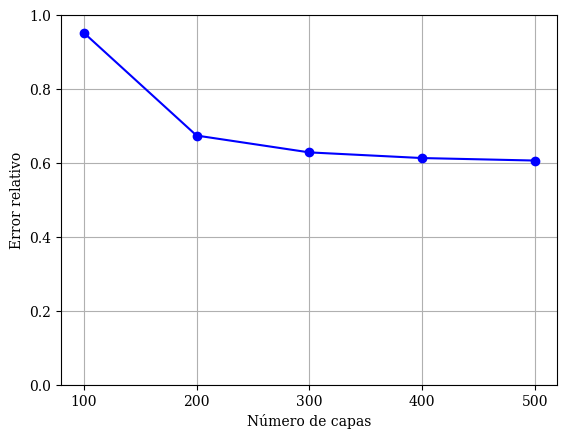

In [16]:
n_capas=[100*(i+1) for i in range(5)]
Error=[None]*5
y_er=np.arange(0, 1.05, 0.2)
estrella_prueba_ = StarModel(5, 0.75, 0.2, 40, 12, 1.5)
for i in range(5):
    estrella_prueba_.calculate(optimizar=True,mallado_final=False,parametros_optimos=False,magnitudes_extra=False,n_capas=n_capas[i],it=1)
    Error[i]=estrella_prueba_.error()
plt.plot(n_capas, Error, marker='o', linestyle='-', color='b')

plt.xlabel("Número de capas")
plt.ylabel("Error relativo")
plt.yticks(y_er)
plt.xticks(n_capas)
plt.grid(True)

plt.show()

Regarding the number of optimization iterations.

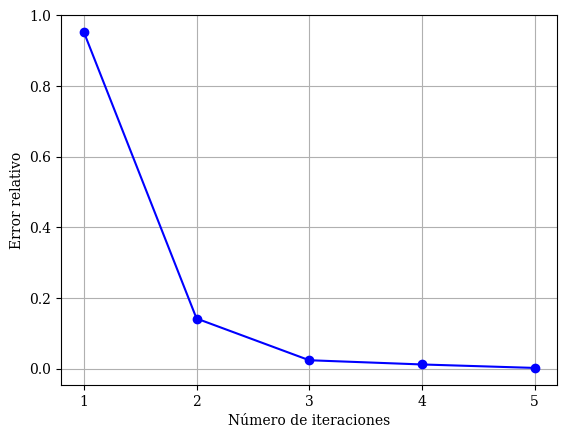

In [17]:
n_it=[i+1 for i in range(5)]
Error=[None]*5
y_er=np.arange(0, 1.05, 0.2)
estrella_prueba = StarModel(5, 0.75, 0.2, 40, 12, 1.5)
for i in range(5):
    estrella_prueba.calculate(optimizar=True,mallado_final=False,parametros_optimos=False,magnitudes_extra=False,it=n_it[i])
    Error[i]=estrella_prueba.error()

plt.plot(n_it, Error, marker='o', linestyle='-', color='b')

plt.xlabel("Número de iteraciones")
plt.ylabel("Error relativo")
plt.xticks(n_it)
plt.yticks(y_er)
plt.grid(True)

plt.show()

## Stellar evolution in the HR diagram as a function of mass

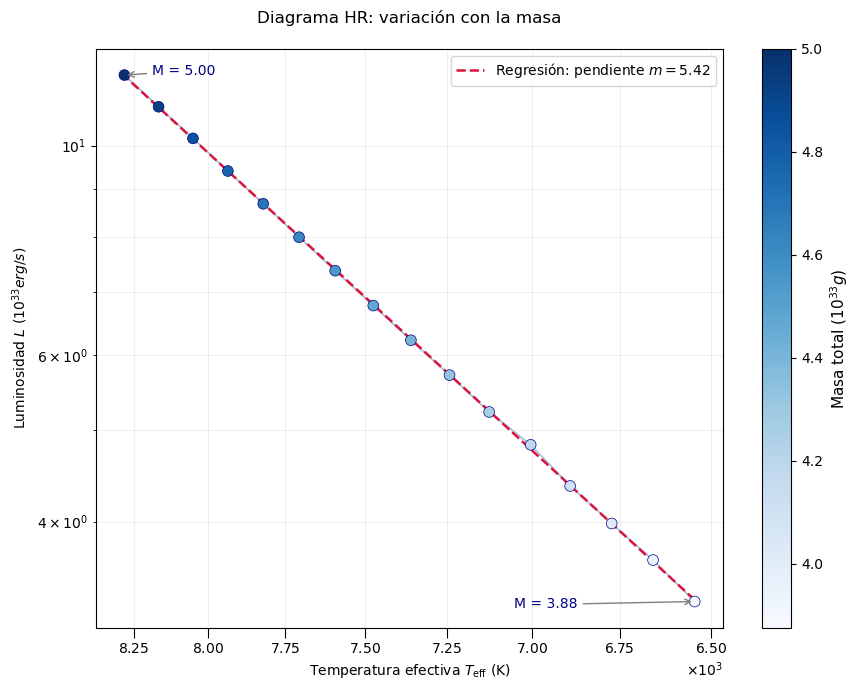

In [44]:
M_ = [5 - 0.075 * i for i in range(16)]
L = [None] * 16
T = [None] * 16
L_ = 45.5
R_ = 11.5

for i in range(16):
    _est__ = StarModel(M_[i], 0.75, 0.2, L_, R_, 1.5)
    _est__.calculate(
        parametros_optimos=False, magnitudes_extra=False,
        mallado_final=False, all_mallados=False,
        r_inf=R_ - 0.8, r_sup=R_ + 0.2,
        L_inf=L_ - 10, L_sup=L_ + 5
    )
    L[i] = _est__.Ltot
    T[i] = _est__.effective_temp()
    L_ = int(_est__.Ltot)
    R_ = int(_est__.Rtot * 10) / 10

L_sol = [l / 3.828 for l in L]
norm_masa = plt.Normalize(vmin=min(M_), vmax=max(M_))
cmap_masa = plt.colormaps['Blues']

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(T, L_sol, linestyle='-', color='steelblue', lw=1.2, alpha=0.5, zorder=1)

sc = ax.scatter(T, L_sol, c=M_, cmap='Blues', norm=norm_masa,
                s=60, zorder=3, edgecolors='navy', linewidths=0.5)

ax.annotate(
    f'M = {M_[0]:.2f}',
    xy=(T[0], L_sol[0]),
    xytext=(20, 0),
    textcoords='offset points',
    fontsize=10, color='navy',
    arrowprops=dict(arrowstyle='->', color='gray', lw=1),
)
ax.annotate(
    f'M = {M_[-1]:.2f}',
    xy=(T[-1], L_sol[-1]),
    xytext=(-130, -5),
    textcoords='offset points',
    fontsize=10, color='navy',
    arrowprops=dict(arrowstyle='->', color='gray', lw=1),
)

x_arr = np.array(T)
y_arr = np.array(L_sol)
m_reg, b_reg = np.polyfit(np.log10(x_arr), np.log10(y_arr), 1)
x_recta = np.linspace(min(x_arr), max(x_arr), 200)
y_recta = 10 ** (m_reg * np.log10(x_recta) + b_reg)
ax.plot(x_recta, y_recta, color='crimson', lw=1.8, ls='--',
        label=fr'Regresión: pendiente $m = {m_reg:.2f}$', zorder=2)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'Masa total $(10^{33}g)$', fontsize=11)

ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'Temperatura efectiva $T_\mathrm{eff}\ \mathrm{(K)}$')
ax.set_ylabel(r'Luminosidad $L\ (10^{33}erg/s)$')
ax.set_title('Diagrama HR: variación con la masa\n')
ax.legend(loc='upper right')


ticks_x = np.arange(6500, 8500, 250)
ax.xaxis.set_major_locator(FixedLocator(ticks_x))
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
ax.tick_params(axis='x', which='major', length=7, rotation=0)

plt.tight_layout()
plt.grid(True, which='both', alpha=0.2)
plt.show()

## Stellar evolution in the HR diagram as a function of metallicity

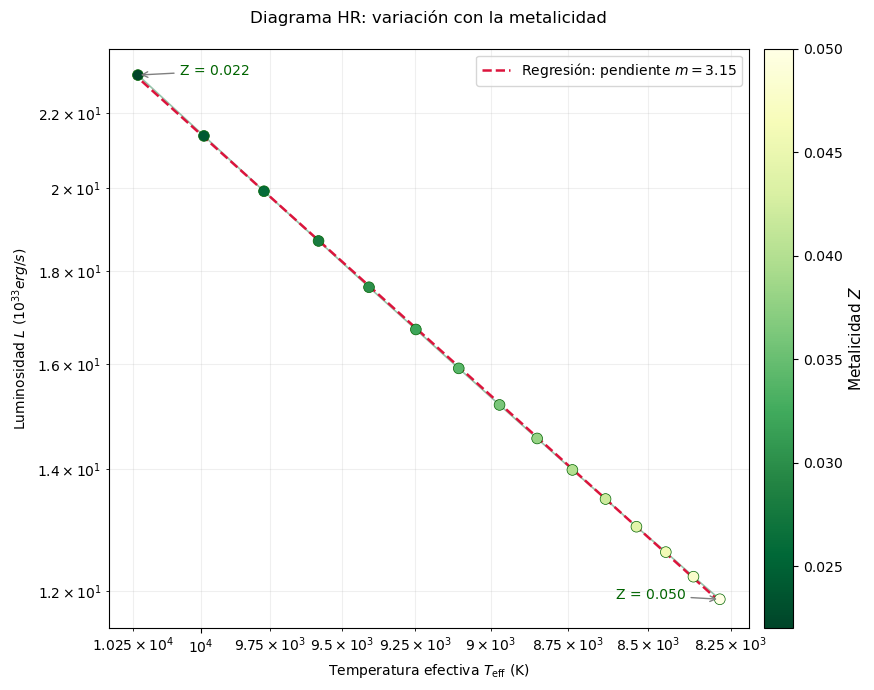

In [46]:
Z_ = [0.05 - 0.002 * i for i in range(15)]
L2 = [None] * 15
T2 = [None] * 15
L_ = 45.0
R_ = 11.5

for i in range(15):
    _est__ = StarModel(5, 0.8 - Z_[i], 0.2, L_, R_, 1.5)
    _est__.calculate(
        parametros_optimos=False, magnitudes_extra=False,
        mallado_final=False, all_mallados=False,
        r_inf=R_ - 0.8, r_sup=R_ + 0.2,
        L_inf=L_ - 2, L_sup=L_ + 13
    )
    L2[i] = _est__.Ltot
    T2[i] = _est__.effective_temp()
    L_ = int(_est__.Ltot)
    R_ = int(_est__.Rtot * 10) / 10

L2_sol = [l / 3.828 for l in L2]

norm_Z = plt.Normalize(vmin=min(Z_), vmax=max(Z_))
cmap_Z = plt.colormaps['YlGn_r']

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(T2, L2_sol, linestyle='-', color='seagreen', lw=1.2, alpha=0.5, zorder=1)

sc2 = ax.scatter(T2, L2_sol, c=Z_, cmap='YlGn_r', norm=norm_Z,
                 s=60, zorder=3, edgecolors='darkgreen', linewidths=0.5)


ax.annotate(
    f'Z = {Z_[0]:.3f}',
    xy=(T2[0], L2_sol[0]),
    xytext=(-75, 0),
    textcoords='offset points',
    fontsize=10, color='darkgreen',
    arrowprops=dict(arrowstyle='->', color='gray', lw=1),
)
ax.annotate(
    f'Z = {Z_[-1]:.3f}',
    xy=(T2[-1], L2_sol[-1]),
    xytext=(30, 0),
    textcoords='offset points',
    fontsize=10, color='darkgreen',
    arrowprops=dict(arrowstyle='->', color='gray', lw=1),
)


x_arr2 = np.array(T2)
y_arr2 = np.array(L2_sol)
m_reg2, b_reg2 = np.polyfit(np.log10(x_arr2), np.log10(y_arr2), 1)
x_recta2 = np.linspace(min(x_arr2), max(x_arr2), 200)
y_recta2 = 10 ** (m_reg2 * np.log10(x_recta2) + b_reg2)
ax.plot(x_recta2, y_recta2, color='crimson', lw=1.8, ls='--',
        label=fr'Regresión: pendiente $m = {m_reg2:.2f}$', zorder=2)

cbar2 = plt.colorbar(sc2, ax=ax, pad=0.02)
cbar2.set_label(r'Metalicidad $Z$', fontsize=11)

ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'Temperatura efectiva $T_\mathrm{eff}\ \mathrm{(K)}$')
ax.set_ylabel(r'Luminosidad $L\ (10^{33}erg/s)$')
ax.set_title('Diagrama HR: variación con la metalicidad\n')
ax.legend(loc='upper right')

plt.tight_layout()
plt.grid(True, which='both', alpha=0.2)
plt.show()